# Notebook 05 — Modelos Clásicos
**Predicción de Diagnóstico de Cáncer · UAX 2025/2026**

Sección cubierta: **Sección 5 — Modelos Clásicos con Optuna**

Contenido:
- 5.1 Carga de artefactos del preprocesado
- 5.2 Baseline — Regresión Logística
- 5.3 Random Forest con Optuna
- 5.4 XGBoost con Optuna
- 5.5 LightGBM con Optuna
- 5.6 Curvas de convergencia de Optuna
- 5.7 Feature importance de los mejores modelos
- 5.8 Resumen de validación cruzada + Brier Score
- 5.9 Guardado de modelos y probabilidades

**Carga:** `data/processed/` (arrays numpy + meta.json)
**Genera:** modelos en `models/`, probabilidades en `data/processed/probas_classical.joblib`

---
## Setup

In [2]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    accuracy_score, brier_score_loss, average_precision_score
)
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')

RANDOM_STATE  = 42
CV_FOLDS      = 5
OPTUNA_TRIALS = 20

ROOT      = os.path.abspath('..')
DATA_PROC = os.path.join(ROOT, 'data', 'processed')
MODELS    = os.path.join(ROOT, 'models')
OUT_FIGS  = os.path.join(ROOT, 'outputs', 'figures')
OUT_TABS  = os.path.join(ROOT, 'outputs', 'tables')
os.makedirs(MODELS, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})

C:\Users\Propietario\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---
## 5.1 Carga de artefactos

In [3]:
X_train = np.load(os.path.join(DATA_PROC, 'X_train.npy'))
X_test  = np.load(os.path.join(DATA_PROC, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)

CLASS_WEIGHT_DICT = {int(k): v for k, v in meta['class_weight'].items()}
SCALE_POS_WEIGHT  = meta['scale_pos_weight']
FEATURE_NAMES     = meta['feature_names']
ORACLE_AUC        = meta['oracle_auc']

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")
print(f"Features: {len(FEATURE_NAMES)}  |  Oracle AUC techo: {ORACLE_AUC}")
print(f"class_weight: {CLASS_WEIGHT_DICT}")
print(f"scale_pos_weight: {SCALE_POS_WEIGHT:.4f}")

# Diccionario para acumular resultados
cv_records   = []   # resultados CV
best_studies = {}   # estudios Optuna por modelo

X_train: (40000, 49)  y_train: (40000,)
X_test:  (10001, 49)   y_test:  (10001,)
Features: 49  |  Oracle AUC techo: 0.8335
class_weight: {0: 0.6194827319188477, 1: 2.592352559948153}
scale_pos_weight: 4.1847


---
## 5.2 Baseline — Regresión Logística

Punto de referencia para justificar que la complejidad añadida de los modelos
de ensemble tiene sentido. Sin baseline no hay argumento de mejora.

In [4]:
lr = LogisticRegression(
    class_weight=CLASS_WEIGHT_DICT,
    max_iter=1000,
    random_state=RANDOM_STATE
)
lr.fit(X_train, y_train)

cv_lr = cross_validate(lr, X_train, y_train, cv=skf,
                       scoring=['f1','roc_auc'], n_jobs=-1)
brier_lr = np.mean(cross_val_score(lr, X_train, y_train, cv=skf,
                                   scoring='neg_brier_score', n_jobs=-1)) * -1

cv_records.append({
    'modelo':        'LogReg (baseline)',
    'f1_mean':       cv_lr['test_f1'].mean(),
    'f1_std':        cv_lr['test_f1'].std(),
    'auc_mean':      cv_lr['test_roc_auc'].mean(),
    'auc_std':       cv_lr['test_roc_auc'].std(),
    'brier_mean':    brier_lr,
})

joblib.dump(lr, os.path.join(MODELS, 'lr_baseline.joblib'))
print(f"LogReg  |  CV F1={cv_lr['test_f1'].mean():.4f} +/- {cv_lr['test_f1'].std():.4f}"
      f"  AUC={cv_lr['test_roc_auc'].mean():.4f}"
      f"  Brier={brier_lr:.4f}")

LogReg  |  CV F1=0.5413 +/- 0.0035  AUC=0.8315  Brier=0.1659


---
## 5.3 Random Forest con Optuna

Ensamble de árboles de decisión independientes. Robusto a outliers,
captura interacciones no lineales y proporciona importancia de variables
interpretable directamente.

In [5]:
def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 300),
        'max_depth':        trial.suggest_int('max_depth', 5, 30),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight':     'balanced',
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
    }
    model = RandomForestClassifier(**params)
    return cross_val_score(model, X_train, y_train,
                           cv=skf, scoring='f1', n_jobs=-1).mean()

rf_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
rf_study.optimize(rf_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
best_studies['Random Forest'] = rf_study

best_rf = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
best_rf.fit(X_train, y_train)

cv_rf  = cross_validate(best_rf, X_train, y_train, cv=skf,
                        scoring=['f1','roc_auc'], n_jobs=-1)
brier_rf = np.mean(cross_val_score(best_rf, X_train, y_train, cv=skf,
                                   scoring='neg_brier_score', n_jobs=-1)) * -1

cv_records.append({
    'modelo':     'Random Forest',
    'f1_mean':    cv_rf['test_f1'].mean(),
    'f1_std':     cv_rf['test_f1'].std(),
    'auc_mean':   cv_rf['test_roc_auc'].mean(),
    'auc_std':    cv_rf['test_roc_auc'].std(),
    'brier_mean': brier_rf,
})

joblib.dump(best_rf, os.path.join(MODELS, 'rf_best.joblib'))
print(f"RF best params: {rf_study.best_params}")
print(f"RF      |  CV F1={cv_rf['test_f1'].mean():.4f} +/- {cv_rf['test_f1'].std():.4f}"
      f"  AUC={cv_rf['test_roc_auc'].mean():.4f}"
      f"  Brier={brier_rf:.4f}")

Best trial: 11. Best value: 0.542591: 100%|██████████| 20/20 [06:29<00:00, 19.49s/it]


RF best params: {'n_estimators': 174, 'max_depth': 29, 'min_samples_leaf': 16, 'max_features': 'sqrt'}
RF      |  CV F1=0.5426 +/- 0.0041  AUC=0.8230  Brier=0.1499


---
## 5.4 XGBoost con Optuna

Gradient boosting secuencial. Estado del arte en tabular data,
maneja el desbalance con `scale_pos_weight`.

In [6]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 700),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': SCALE_POS_WEIGHT,
        'eval_metric':      'logloss',
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
    }
    model = xgb.XGBClassifier(**params)
    return cross_val_score(model, X_train, y_train,
                           cv=skf, scoring='f1', n_jobs=-1).mean()

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
xgb_study.optimize(xgb_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
best_studies['XGBoost'] = xgb_study

best_xgb = xgb.XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='logloss',
    random_state=RANDOM_STATE, n_jobs=-1
)
best_xgb.fit(X_train, y_train)

cv_xgb  = cross_validate(best_xgb, X_train, y_train, cv=skf,
                         scoring=['f1','roc_auc'], n_jobs=-1)
brier_xgb = np.mean(cross_val_score(best_xgb, X_train, y_train, cv=skf,
                                    scoring='neg_brier_score', n_jobs=-1)) * -1

cv_records.append({
    'modelo':     'XGBoost',
    'f1_mean':    cv_xgb['test_f1'].mean(),
    'f1_std':     cv_xgb['test_f1'].std(),
    'auc_mean':   cv_xgb['test_roc_auc'].mean(),
    'auc_std':    cv_xgb['test_roc_auc'].std(),
    'brier_mean': brier_xgb,
})

joblib.dump(best_xgb, os.path.join(MODELS, 'xgb_best.joblib'))
print(f"XGB best params: {xgb_study.best_params}")
print(f"XGB     |  CV F1={cv_xgb['test_f1'].mean():.4f} +/- {cv_xgb['test_f1'].std():.4f}"
      f"  AUC={cv_xgb['test_roc_auc'].mean():.4f}"
      f"  Brier={brier_xgb:.4f}")

Best trial: 9. Best value: 0.537442: 100%|██████████| 20/20 [02:50<00:00,  8.52s/it]


XGB best params: {'n_estimators': 314, 'max_depth': 4, 'learning_rate': 0.06333268775321843, 'subsample': 0.6563696899899051, 'colsample_bytree': 0.9208787923016158, 'reg_alpha': 0.0019870215385428634, 'reg_lambda': 8.862326508576253}
XGB     |  CV F1=0.5374 +/- 0.0031  AUC=0.8255  Brier=0.1631


---
## 5.5 LightGBM con Optuna

Gradient boosting basado en histogramas. Más rápido que XGBoost en datasets
grandes y habitualmente competitivo en rendimiento.

In [7]:
def lgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 700),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight':     'balanced',
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
        'verbose':          -1,
    }
    model = lgb.LGBMClassifier(**params)
    return cross_val_score(model, X_train, y_train,
                           cv=skf, scoring='f1', n_jobs=-1).mean()

lgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
lgb_study.optimize(lgb_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
best_studies['LightGBM'] = lgb_study

best_lgb = lgb.LGBMClassifier(
    **lgb_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
best_lgb.fit(X_train, y_train)

cv_lgb  = cross_validate(best_lgb, X_train, y_train, cv=skf,
                         scoring=['f1','roc_auc'], n_jobs=-1)
brier_lgb = np.mean(cross_val_score(best_lgb, X_train, y_train, cv=skf,
                                    scoring='neg_brier_score', n_jobs=-1)) * -1

cv_records.append({
    'modelo':     'LightGBM',
    'f1_mean':    cv_lgb['test_f1'].mean(),
    'f1_std':     cv_lgb['test_f1'].std(),
    'auc_mean':   cv_lgb['test_roc_auc'].mean(),
    'auc_std':    cv_lgb['test_roc_auc'].std(),
    'brier_mean': brier_lgb,
})

joblib.dump(best_lgb, os.path.join(MODELS, 'lgb_best.joblib'))
print(f"LGB best params: {lgb_study.best_params}")
print(f"LGB     |  CV F1={cv_lgb['test_f1'].mean():.4f} +/- {cv_lgb['test_f1'].std():.4f}"
      f"  AUC={cv_lgb['test_roc_auc'].mean():.4f}"
      f"  Brier={brier_lgb:.4f}")

Best trial: 1. Best value: 0.539045: 100%|██████████| 20/20 [03:05<00:00,  9.25s/it]


LGB best params: {'n_estimators': 461, 'max_depth': 8, 'learning_rate': 0.010725209743171996, 'num_leaves': 147, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}
LGB     |  CV F1=0.5390 +/- 0.0019  AUC=0.8230  Brier=0.1549


---
## 5.6 Curvas de convergencia de Optuna

Muestra cómo mejora el F1 a lo largo de los trials para cada modelo.
Justifica visualmente la búsqueda bayesiana: converge rápido y los últimos
trials ya no aportan mejora significativa.

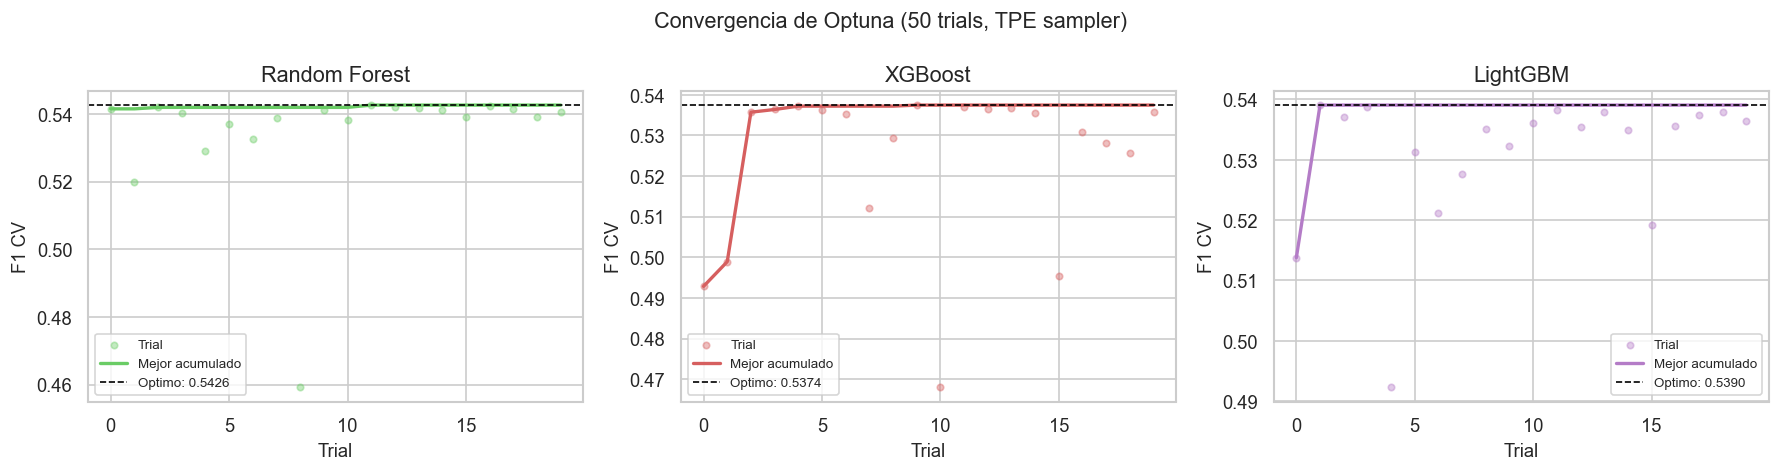

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'Random Forest': '#6ACC65', 'XGBoost': '#D65F5F', 'LightGBM': '#B47CC7'}

for ax, (name, study) in zip(axes, best_studies.items()):
    trials_df = study.trials_dataframe()
    # Mejor valor acumulado hasta cada trial
    best_so_far = trials_df['value'].cummax()

    ax.scatter(trials_df.index, trials_df['value'],
               alpha=0.4, s=15, color=colors[name], label='Trial')
    ax.plot(trials_df.index, best_so_far,
            color=colors[name], linewidth=2, label='Mejor acumulado')
    ax.axhline(study.best_value, color='black', linestyle='--',
               linewidth=1, label=f'Optimo: {study.best_value:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('F1 CV')
    ax.set_title(name)
    ax.legend(fontsize=8)

plt.suptitle('Convergencia de Optuna (50 trials, TPE sampler)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '13_optuna_convergence.png'), bbox_inches='tight')
plt.show()

---
## 5.7 Feature importance de los modelos entrenados

Top 20 features según RF y LightGBM (impurity-based).
Valida que los modelos aprenden las variables correctas y que
el feature engineering apuntó en la dirección adecuada.

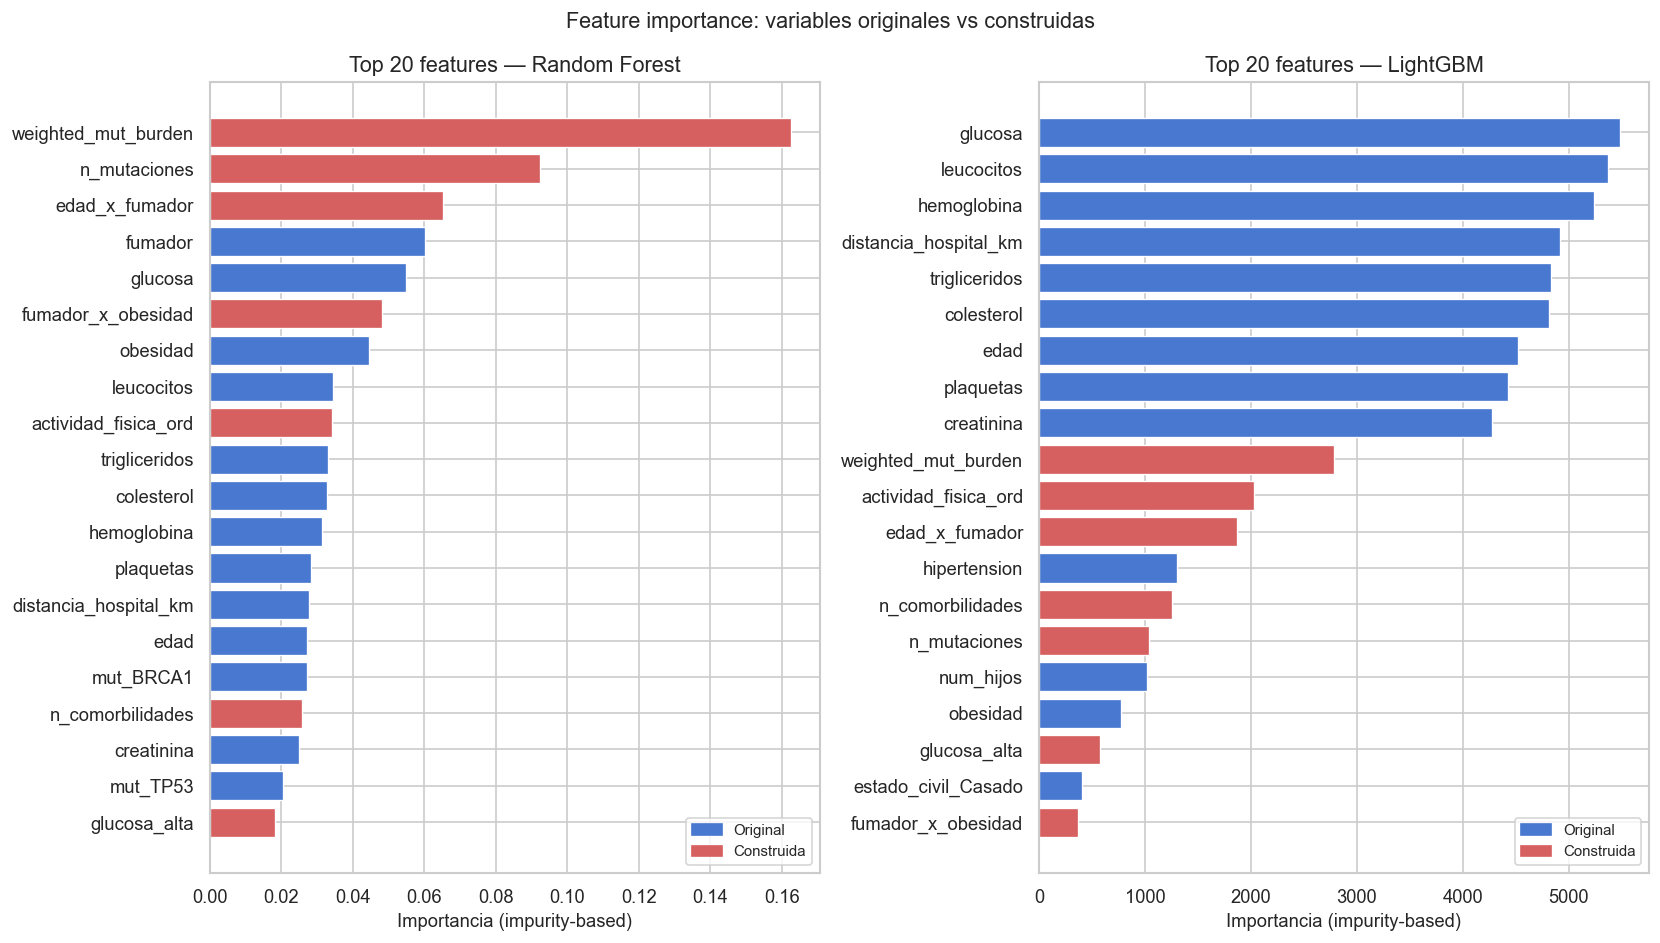

In [9]:
CONSTRUCTED = {
    'n_mutaciones', 'n_comorbilidades', 'weighted_mut_burden',
    'glucosa_alta', 'hemoglobina_baja', 'leucocitos_alto',
    'actividad_fisica_ord', 'edad_bin',
    'fumador_x_obesidad', 'BRCA1_x_TP53', 'edad_x_fumador'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (model, name) in zip(axes, [
    (best_rf,  'Random Forest'),
    (best_lgb, 'LightGBM'),
]):
    importances = model.feature_importances_
    feat_imp = (pd.DataFrame({'feature': FEATURE_NAMES, 'importance': importances})
                  .sort_values('importance', ascending=False)
                  .head(20))

    bar_colors = ['#D65F5F' if f in CONSTRUCTED else '#4878CF'
                  for f in feat_imp['feature']]

    ax.barh(feat_imp['feature'][::-1], feat_imp['importance'][::-1],
            color=bar_colors[::-1], edgecolor='white', linewidth=0.8)
    ax.set_xlabel('Importancia (impurity-based)')
    ax.set_title(f'Top 20 features — {name}')

    patch_orig = mpatches.Patch(color='#4878CF', label='Original')
    patch_new  = mpatches.Patch(color='#D65F5F', label='Construida')
    ax.legend(handles=[patch_orig, patch_new], fontsize=9)

plt.suptitle('Feature importance: variables originales vs construidas', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_FIGS, '14_feature_importance_models.png'), bbox_inches='tight')
plt.show()

---
## 5.8 Resumen de validación cruzada

Tabla comparativa **antes de abrir el test**. La selección del mejor modelo
clásico se hace aquí, sin ver los datos de evaluación final.

In [10]:
df_cv = pd.DataFrame(cv_records)
df_cv['f1_cv']  = df_cv.apply(lambda r: f"{r['f1_mean']:.4f} +/- {r['f1_std']:.4f}", axis=1)
df_cv['auc_cv'] = df_cv.apply(lambda r: f"{r['auc_mean']:.4f} +/- {r['auc_std']:.4f}", axis=1)
df_cv['brier']  = df_cv['brier_mean'].round(4)
df_cv['pct_oracle'] = (df_cv['auc_mean'] / ORACLE_AUC * 100).round(1)

print("=== Resultados en Validacion Cruzada (train, 5 folds) ===")
print()
cols_show = ['modelo', 'f1_cv', 'auc_cv', 'brier', 'pct_oracle']
print(df_cv[cols_show].to_string(index=False))
print()
print(f"Oracle AUC (techo teorico): {ORACLE_AUC}")
print("pct_oracle = % del techo teorico alcanzado en CV")
print()
print("Brier Score: mas bajo es mejor (0 = perfecto, 0.25 = modelo sin info)")
print("Modelos con Brier < 0.15 tienen probabilidades razonablemente calibradas")

df_cv[cols_show].to_csv(os.path.join(OUT_TABS, 'cv_results.csv'), index=False)
print()

# Identificar mejor modelo clásico por F1
best_classic_name = df_cv[df_cv['modelo'] != 'LogReg (baseline)'].sort_values(
    'f1_mean', ascending=False).iloc[0]['modelo']
print(f"Mejor modelo clasico por F1 en CV: {best_classic_name}")

=== Resultados en Validacion Cruzada (train, 5 folds) ===

           modelo             f1_cv            auc_cv  brier  pct_oracle
LogReg (baseline) 0.5413 +/- 0.0035 0.8315 +/- 0.0025 0.1659        99.8
    Random Forest 0.5426 +/- 0.0041 0.8230 +/- 0.0032 0.1499        98.7
          XGBoost 0.5374 +/- 0.0031 0.8255 +/- 0.0025 0.1631        99.0
         LightGBM 0.5390 +/- 0.0019 0.8230 +/- 0.0024 0.1549        98.7

Oracle AUC (techo teorico): 0.8335
pct_oracle = % del techo teorico alcanzado en CV

Brier Score: mas bajo es mejor (0 = perfecto, 0.25 = modelo sin info)
Modelos con Brier < 0.15 tienen probabilidades razonablemente calibradas

Mejor modelo clasico por F1 en CV: Random Forest


---
## 5.9 Guardado de probabilidades sobre test

In [ ]:
# Probabilidades sobre X_test para cada modelo
# Se usarán en notebook 07 (evaluación) junto con las de la MLP
probas = {
    'LogReg (baseline)': lr.predict_proba(X_test)[:, 1],
    'Random Forest':     best_rf.predict_proba(X_test)[:, 1],
    'XGBoost':           best_xgb.predict_proba(X_test)[:, 1],
    'LightGBM':          best_lgb.predict_proba(X_test)[:, 1],
}

joblib.dump(probas, os.path.join(DATA_PROC, 'probas_classical.joblib'))

print("Modelos guardados en models/:")
for fname in ['lr_baseline.joblib','rf_best.joblib',
              'xgb_best.joblib','lgb_best.joblib']:
    size = os.path.getsize(os.path.join(MODELS, fname)) / 1024
    print(f"  {fname:<25} {size:>8.1f} KB")

print()
print("Probabilidades sobre test guardadas en data/processed/probas_classical.joblib")
print()
print("Listo para Notebook 06 — MLP")

Modelos guardados en models/:
  lr_baseline.joblib             1.2 KB
  rf_best.joblib             27383.3 KB
  xgb_best.joblib              526.2 KB
  lgb_best.joblib             6887.1 KB

Probabilidades sobre test guardadas en data/processed/probas_classical.joblib

Listo para Notebook 06 — MLP


: 